# Setting Awal

In [1]:
# ======================================
# 📌 1. Mount Google Drive
# ======================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ======================================
# 📦 2️⃣ Install & Import Library
# ======================================
!pip install emoji seaborn transformers

import pandas as pd
import numpy as np
import pickle
import torch
from transformers import BertTokenizer, BertForTokenClassification, pipeline
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam      # ✅ Tambahkan untuk compile ulang
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import string
import nltk
from nltk.stem import WordNetLemmatizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 18.1 MB/s eta 0:00:00


In [3]:
# ======================================
# 📥 3️⃣ Download Resource NLP
# ======================================
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [4]:
# ======================================
# 🔧 4️⃣ Path file model & data
# ======================================
BERT_MODEL_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/bert_ate_finetuned"
LSTM_MODEL_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/lstm_model.h5"
TOKENIZER_SENTENCE_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/tokenizer_sentence.pkl"
TOKENIZER_ASPECT_PATH = "/content/drive/MyDrive/Tugas Akhir//Model/tokenizer_aspect.pkl"
DATA_FULL_PATH = "/content/drive/MyDrive/Tugas Akhir/3.Analisis/dataset_analisis.csv"

MAX_LEN_SENTENCE = 50
MAX_LEN_ASPECT = 4
BATCH_SIZE = 16

In [5]:
# ======================================
# 📂 5️⃣ Load Dataset Ground Truth
# ======================================
df_full = pd.read_csv(DATA_FULL_PATH)  # kolom: sentence, aspect, sentiment (0/1)
print("Jumlah dataset:", len(df_full))
df_full.head()

Jumlah dataset: 69876


,Movie_ID,Movie_Name,Sentence
0,tt3915174,Puss in Boots: The Last Wish,CS Lewis once said a children's story that onl...
1,tt3915174,Puss in Boots: The Last Wish,I can think of plenty of crummy kids' movies t...
2,tt3915174,Puss in Boots: The Last Wish,I cannot believe I am saying this about a Shre...
3,tt3915174,Puss in Boots: The Last Wish,It works on so many levels: as a high-speed co...
4,tt3915174,Puss in Boots: The Last Wish,The plot literally involves Puss running from ...


# BERT

In [6]:
# ======================================
# 🔠 6️⃣ Load BERT Aspect Extractor
# ======================================
aspect_extractor = pipeline("token-classification",
                            model=BERT_MODEL_PATH,
                            tokenizer=BERT_MODEL_PATH,
                            device=0)   # ⚡ pakai GPU jika tersedia

Device set to use cuda:0


In [7]:
# ======================================
# 🏷️ 7️⃣ Ekstraksi Aspek + Simpan ID dan Nama Film
# ======================================
test_data = df_full.drop_duplicates(subset=['Sentence'])[['Movie_ID', 'Movie_Name', 'Sentence']]

def extract_aspects_batch(sentences, batch_size=32):
    all_aspects = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        batch_aspects = []
        for sentence in batch:
            results = aspect_extractor(sentence)
            aspects = []
            for r in results:
                if 'entity_group' in r:
                    if r['entity_group'] == 'ASP':
                        aspects.append(r['word'])
                elif 'entity' in r:
                    if r['entity'].endswith('ASP'):
                        aspects.append(r['word'])
            batch_aspects.append(aspects)
        all_aspects.extend(batch_aspects)
    return all_aspects

extracted_aspects = extract_aspects_batch(test_data['Sentence'].tolist(), BATCH_SIZE)

# Gabungkan ID, Nama Film, Kalimat, dan Aspek
pairs = []
for (movie_id, movie_name, sentence), aspects in zip(test_data.values, extracted_aspects):
    for asp in aspects:
        pairs.append((movie_id, movie_name, sentence, asp))

print("✅ Total pasangan kalimat-aspek hasil ekstraksi:", len(pairs))
print("Contoh:", pairs[:5])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Total pasangan kalimat-aspek hasil ekstraksi: 38379
Contoh: [('tt3915174', 'Puss in Boots: The Last Wish', "CS Lewis once said a children's story that only appeals to children is not a good children's film in the least.", 'story'), ('tt3915174', 'Puss in Boots: The Last Wish', 'It works on so many levels: as a high-speed comedy, all the jokes land, but as a story about mortality and the meaning of life, this film is oddly compelling and mature.', 'comedy'), ('tt3915174', 'Puss in Boots: The Last Wish', 'It works on so many levels: as a high-speed comedy, all the jokes land, but as a story about mortality and the meaning of life, this film is oddly compelling and mature.', 'jokes'), ('tt3915174', 'Puss in Boots: The Last Wish', 'It works on so many levels: as a high-speed comedy, all the jokes land, but as a story about mortality and the meaning of life, this film is oddly compelling and mature.', 'story'), ('tt3915174', 'Puss in Boots: The Last Wish', 'The plot literally involves Pus

# LSTM

In [8]:
# ======================================
# 🔤 8️⃣ Preprocessing untuk LSTM
# ======================================
def preprocessing(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(f"[{string.punctuation}]", '', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

pairs_cleaned = []
for movie_id, movie_name, sentence, asp in pairs:
    pairs_cleaned.append((movie_id,
                          movie_name,
                          preprocessing(sentence),
                          preprocessing(asp)))

print("✅ Total pasangan kalimat-aspek hasil ekstraksi:", len(pairs))

✅ Total pasangan kalimat-aspek hasil ekstraksi: 38379


In [9]:
# ======================================
# 🔢 9️⃣ Tokenisasi LSTM
# ======================================
with open(TOKENIZER_SENTENCE_PATH, "rb") as f:
    tokenizer_sentence = pickle.load(f)

with open(TOKENIZER_ASPECT_PATH, "rb") as f:
    tokenizer_aspect = pickle.load(f)

sentences_cleaned = [p[2] for p in pairs_cleaned]
aspects_cleaned = [p[3] for p in pairs_cleaned]

seq_sentence = tokenizer_sentence.texts_to_sequences(sentences_cleaned)
seq_aspect = tokenizer_aspect.texts_to_sequences(aspects_cleaned)

pad_sentence = pad_sequences(seq_sentence, maxlen=MAX_LEN_SENTENCE, padding='post', truncating='post')
pad_aspect = pad_sequences(seq_aspect, maxlen=MAX_LEN_ASPECT, padding='post', truncating='post')

In [10]:
# ======================================
# 🔮 🔟 Klasifikasi Sentimen dengan LSTM (GPU jika ada)
# ======================================
lstm_model = load_model(LSTM_MODEL_PATH)

# compile ulang biar jelas
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("🚀 Mulai prediksi dengan LSTM...")
pred_probs = lstm_model.predict([pad_sentence, pad_aspect], batch_size=32)
pred_labels = (pred_probs >= 0.5).astype(int).flatten()

label_map = {0: "negative", 1: "positive"}
pred_sentiments = [label_map[l] for l in pred_labels]

pipeline_results = pd.DataFrame(pairs, columns=["Movie_ID", "Movie_Name", "sentence", "aspect"])
pipeline_results["Predicted_Sentiment"] = pred_sentiments

pipeline_results.head()

🚀 Mulai prediksi dengan LSTM...
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


,Movie_ID,Movie_Name,sentence,aspect,Predicted_Sentiment
0,tt3915174,Puss in Boots: The Last Wish,CS Lewis once said a children's story that onl...,story,negative
1,tt3915174,Puss in Boots: The Last Wish,It works on so many levels: as a high-speed co...,comedy,positive
2,tt3915174,Puss in Boots: The Last Wish,It works on so many levels: as a high-speed co...,jokes,positive
3,tt3915174,Puss in Boots: The Last Wish,It works on so many levels: as a high-speed co...,story,positive
4,tt3915174,Puss in Boots: The Last Wish,The plot literally involves Puss running from ...,plot,negative


# Analisis Umum Aspek Dominan dan Kecenderungan Sentimen

In [11]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_aspect(aspect):
    tokens = nltk.word_tokenize(aspect.lower())
    pos_tags = nltk.pos_tag(tokens, lang='eng')
    lemmatized_tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tags]
    return ' '.join(lemmatized_tokens)

pipeline_results["aspect_lemma"] = pipeline_results["aspect"].apply(lemmatize_aspect)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [12]:
from IPython.display import display

# Hitung jumlah sentimen per aspek per film
sentiment_summary = (
    pipeline_results.groupby(["Movie_Name", "aspect_lemma", "Predicted_Sentiment"])
    .size()
    .unstack(fill_value=0)  # hasilnya ada kolom positive & negative
    .reset_index()
)

# Hapus nama axis kolom yang terbawa dari unstack
sentiment_summary.columns.name = None

# Tambah total frekuensi aspek
sentiment_summary["count"] = sentiment_summary["positive"] + sentiment_summary["negative"]

# Ambil 5 aspek teratas per film berdasarkan frekuensi
top_aspects_per_movie = sentiment_summary.groupby("Movie_Name").apply(
    lambda x: x.sort_values("count", ascending=False).head(5)
).reset_index(drop=True)

# Tampilkan tabel lebih bersih
for movie, group in top_aspects_per_movie.groupby("Movie_Name"):
    print(f"\nTop 5 Aspects for {movie}:\n")
    display(group[["aspect_lemma", "count", "positive", "negative"]])


Top 5 Aspects for Elemental:



/tmp/ipython-input-998019932.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_aspects_per_movie = sentiment_summary.groupby("Movie_Name").apply(


,aspect_lemma,count,positive,negative
0,story,752,484,268
1,character,555,386,169
2,animation,340,312,28
3,plot,186,62,124
4,theme,140,120,20



Top 5 Aspects for Inside Out 2:



,aspect_lemma,count,positive,negative
5,character,645,421,224
6,story,477,283,194
7,sequel,329,220,109
8,animation,261,238,23
9,plot,178,65,113


...

,aspect_lemma,count,positive,negative
40,story,960,631,329
41,character,642,461,181
42,animation,551,506,45
43,theme,261,231,30
44,voice,229,205,24



Top 5 Aspects for Troll Bands Together:



,aspect_lemma,count,positive,negative
45,character,128,70,58
46,song,92,60,32
47,story,80,26,54
48,music,63,49,14
49,animation,55,48,7



Top 5 Aspects for Turning Red:



,aspect_lemma,count,positive,negative
50,character,742,369,373
51,story,606,286,320
52,animation,401,322,79
53,message,258,120,138
54,theme,159,89,70


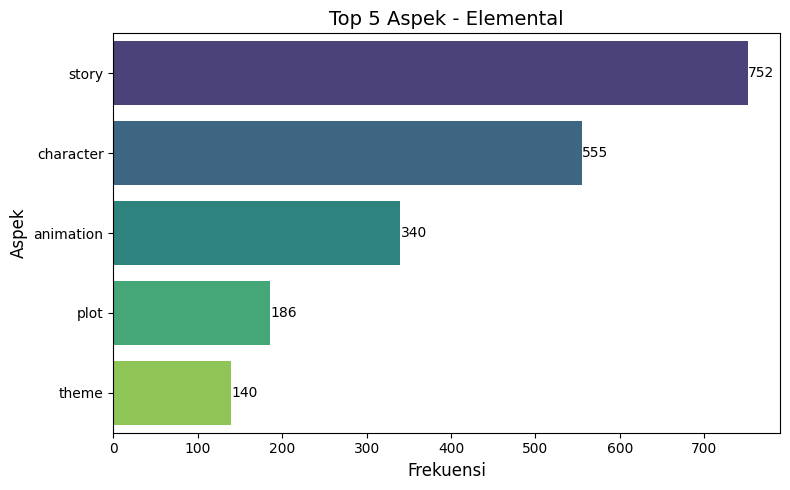

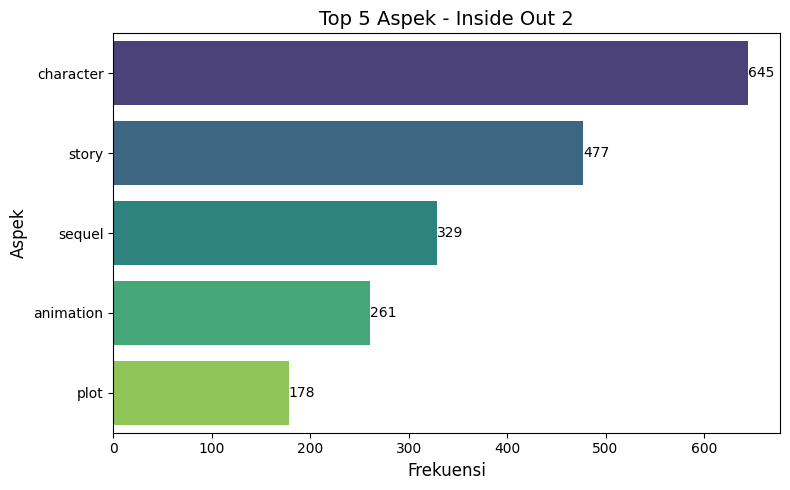

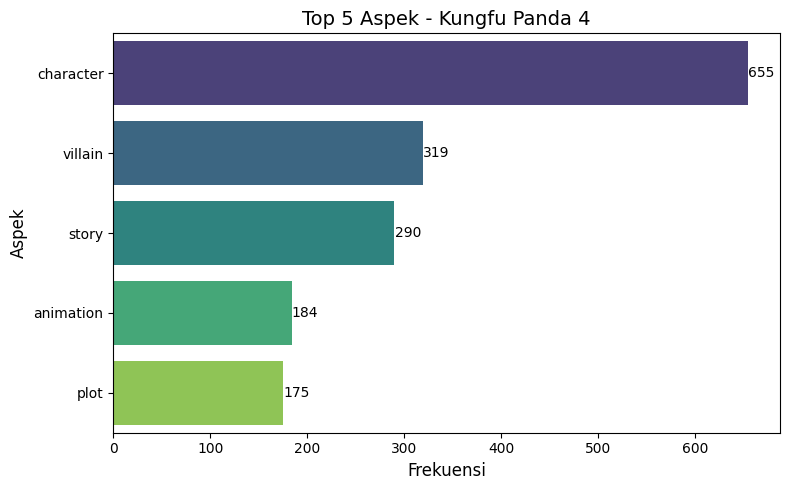

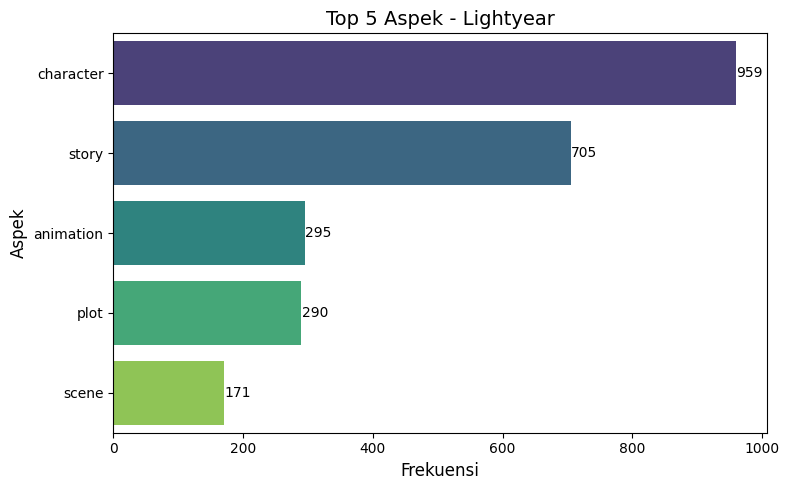

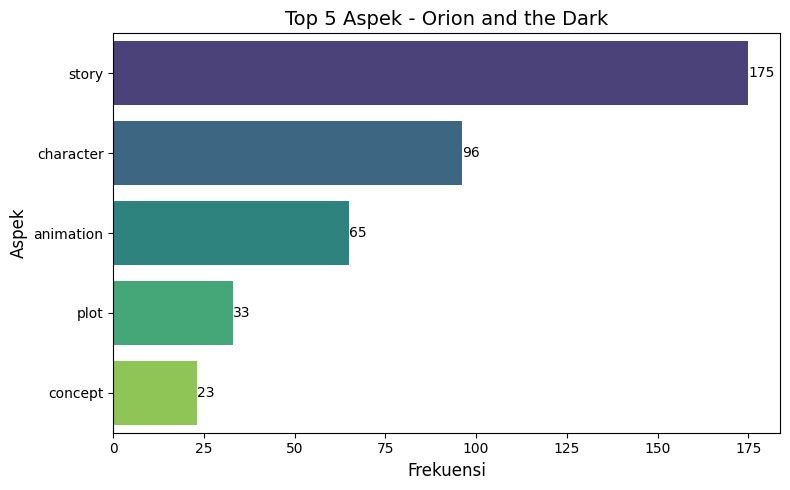

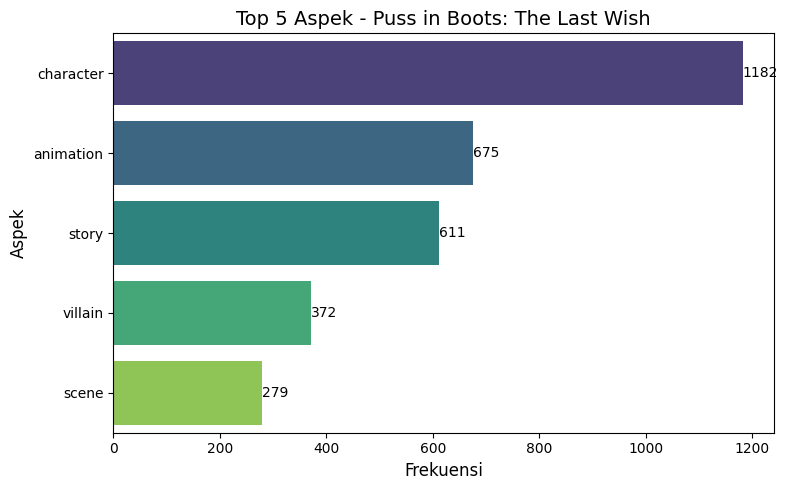

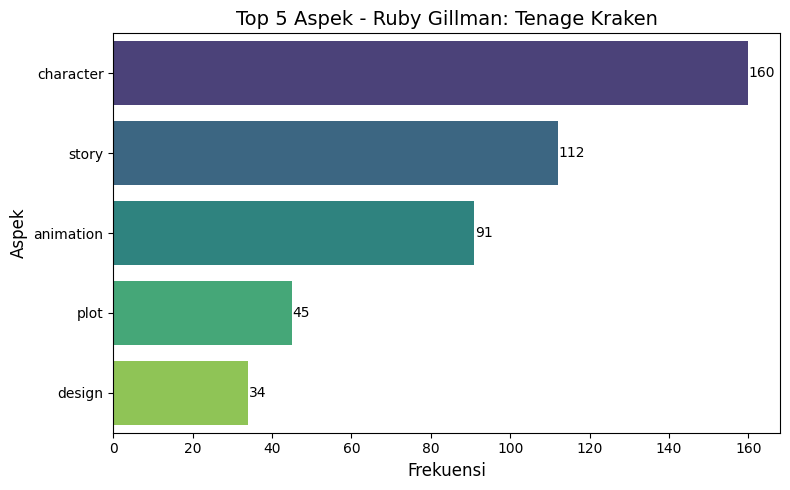

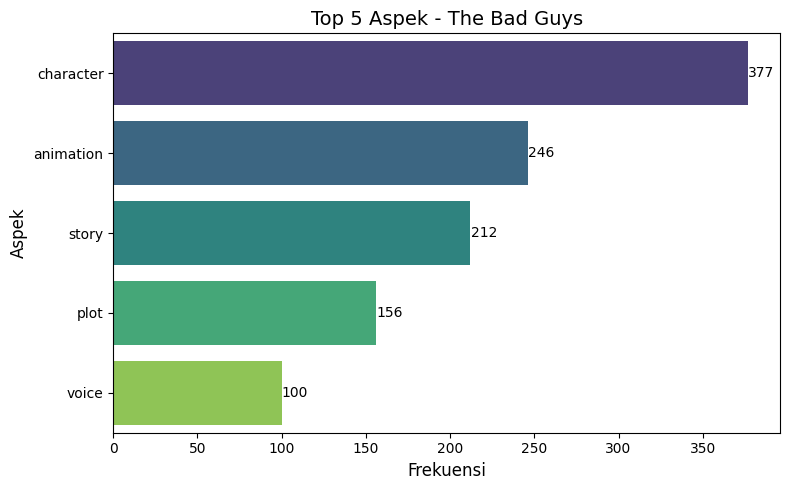

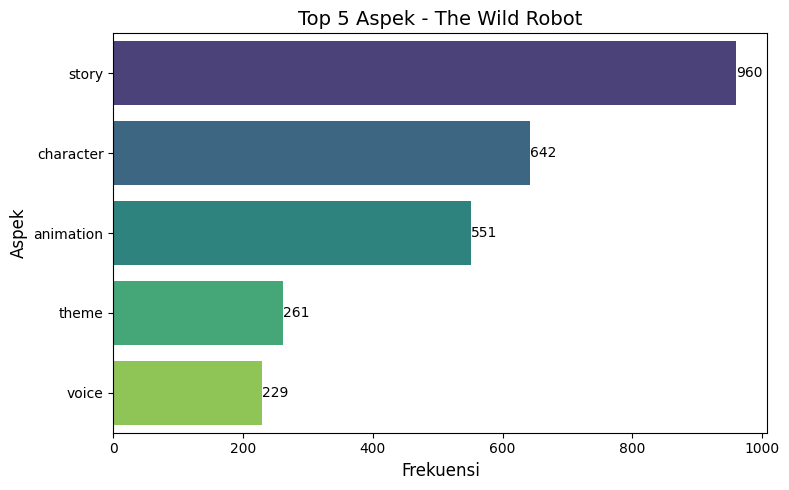

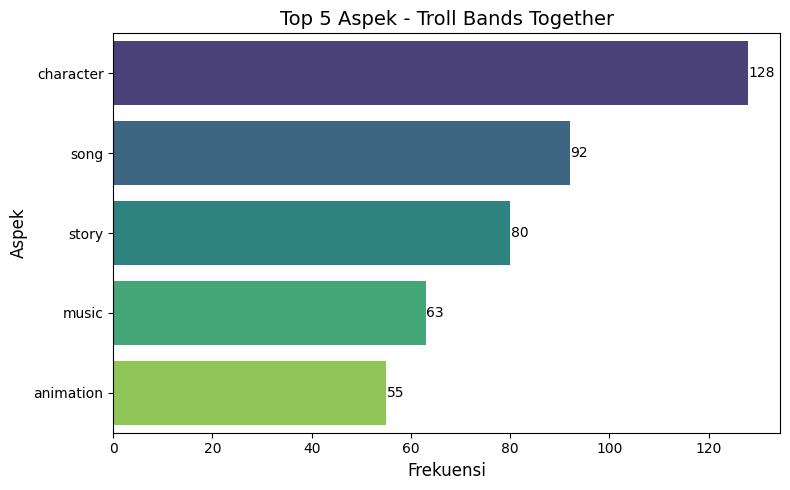

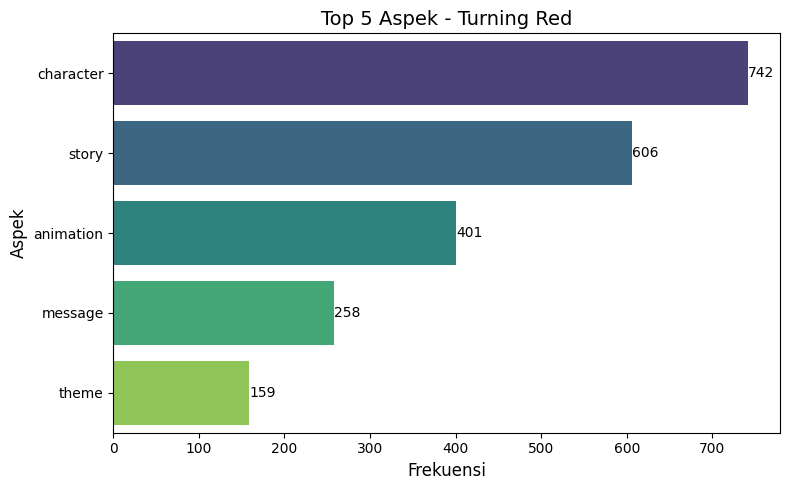

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop setiap film dan buat bar chart 5 aspek teratas
for movie in top_aspects_per_movie["Movie_Name"].unique():
    movie_data = top_aspects_per_movie[top_aspects_per_movie["Movie_Name"] == movie]

    plt.figure(figsize=(8,5))
    colors = sns.color_palette("viridis", len(movie_data))
    sns.barplot(
        x="count",
        y="aspect_lemma",
        data=movie_data,
        hue="aspect_lemma",
        palette=colors,
        legend=False
    )

    plt.title(f"Top 5 Aspek - {movie}", fontsize=14)
    plt.xlabel("Frekuensi", fontsize=12)
    plt.ylabel("Aspek", fontsize=12)

    for index, value in enumerate(movie_data["count"]):
        plt.text(value + 0.1, index, str(value), va='center')

    plt.tight_layout()
    plt.show()

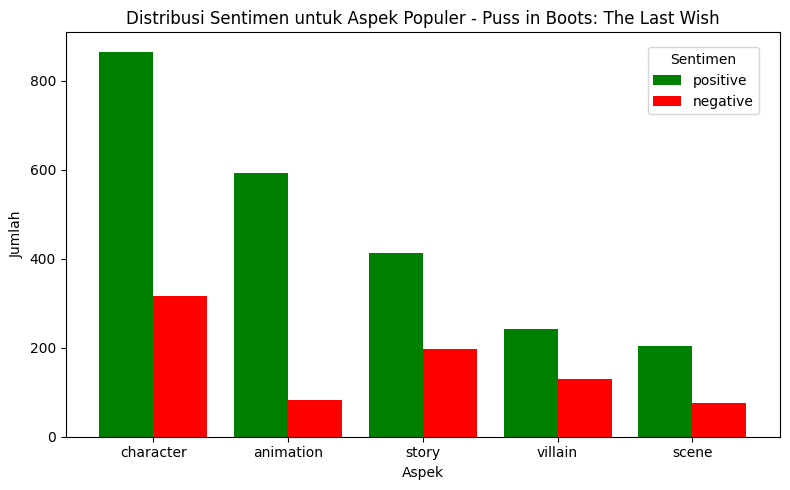

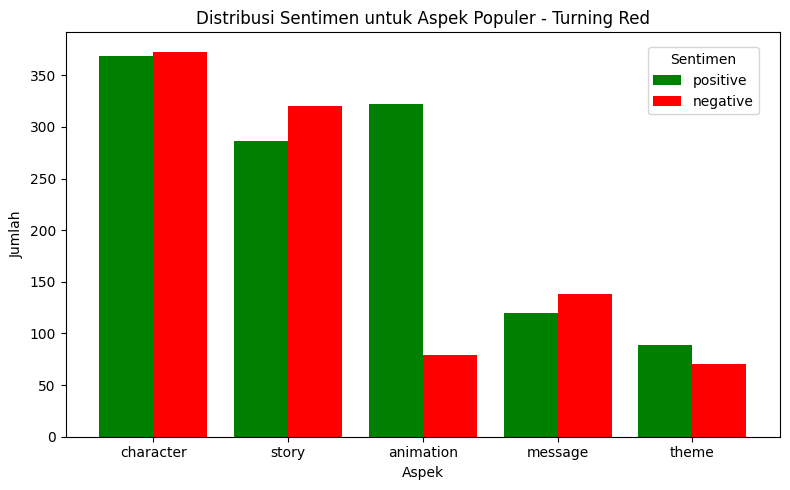

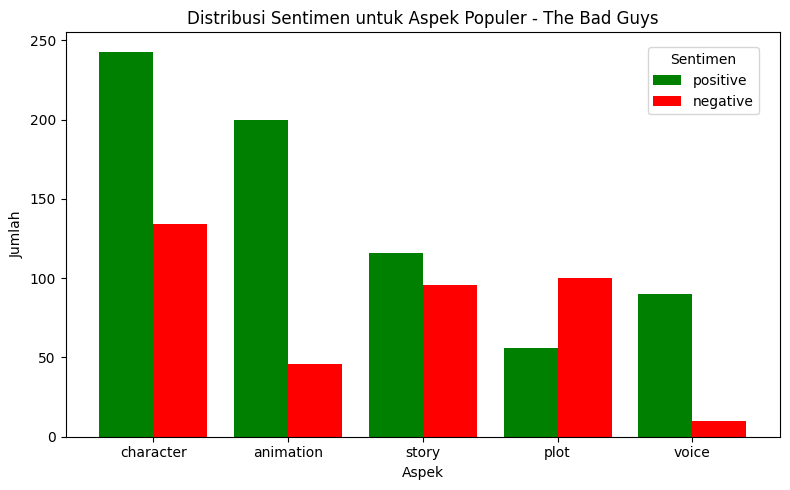

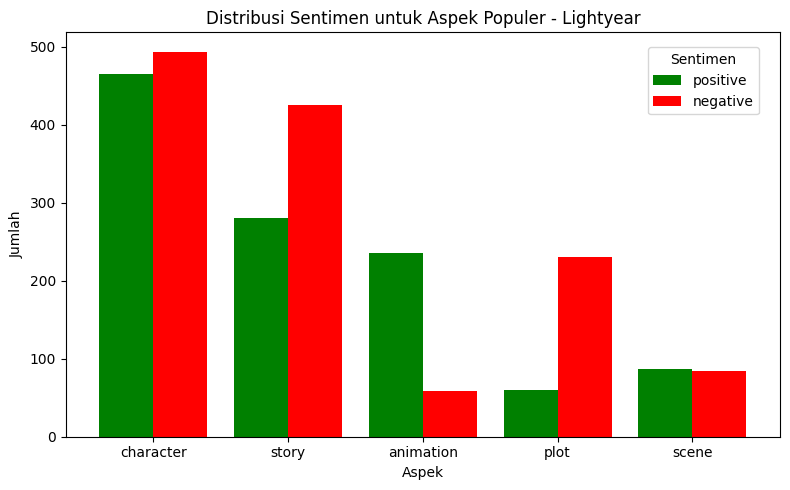

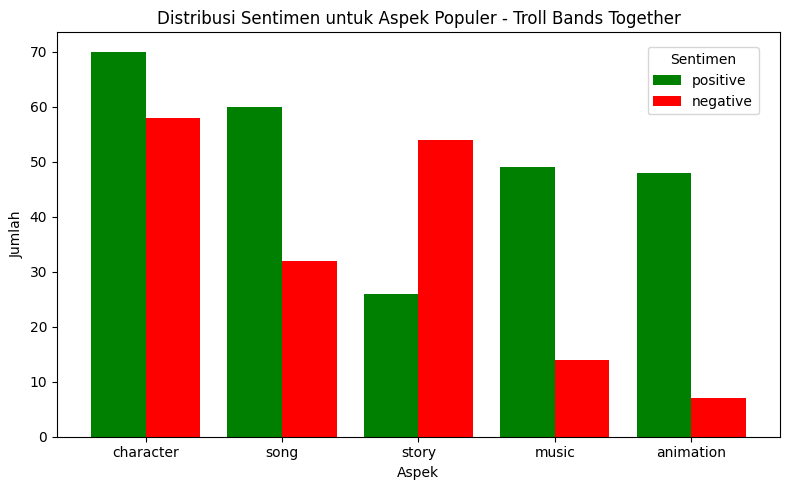

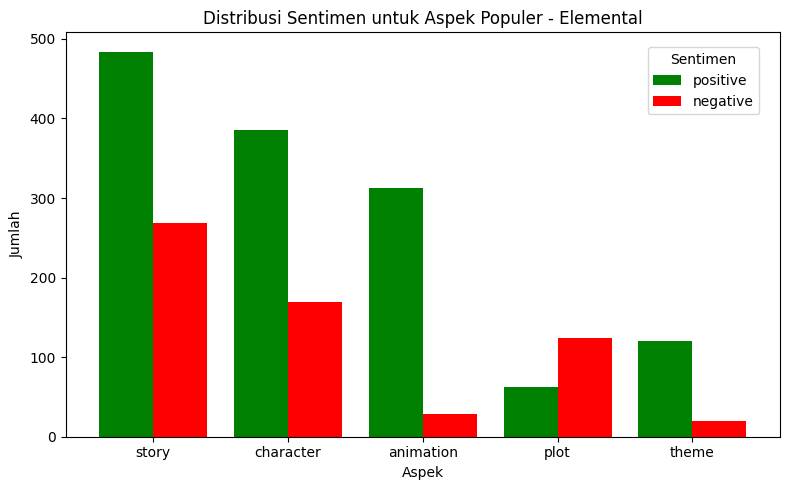

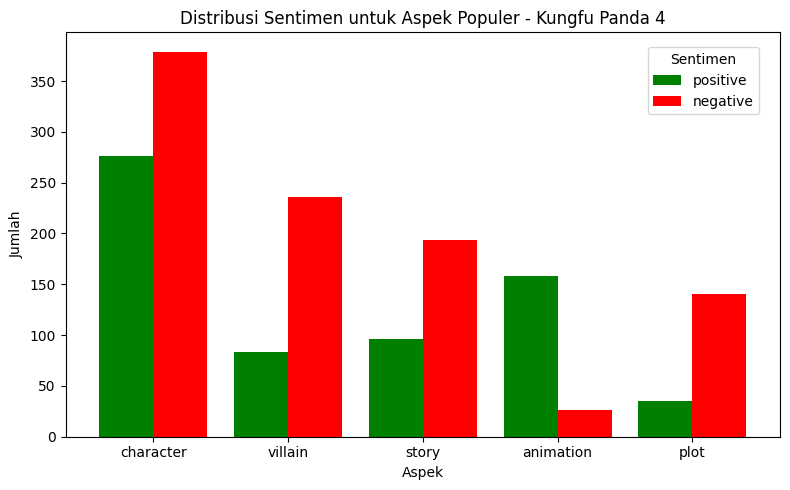

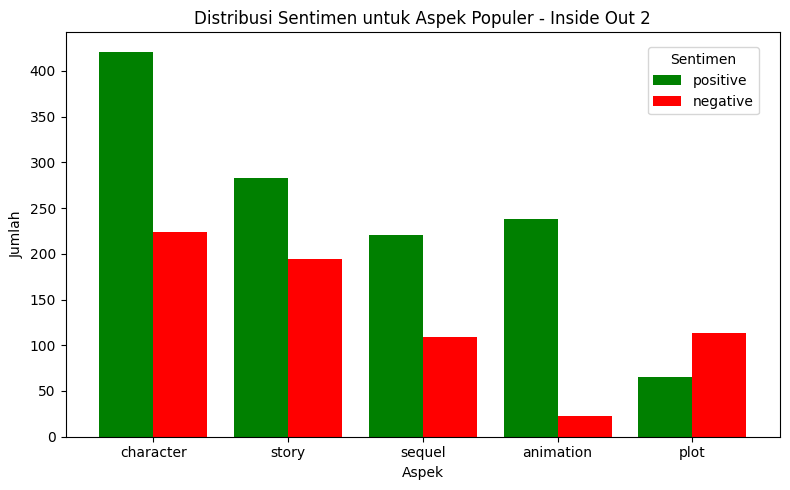

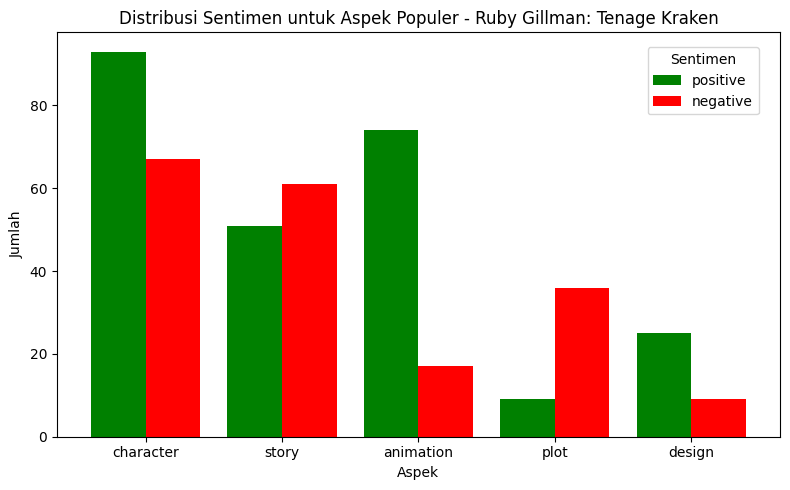

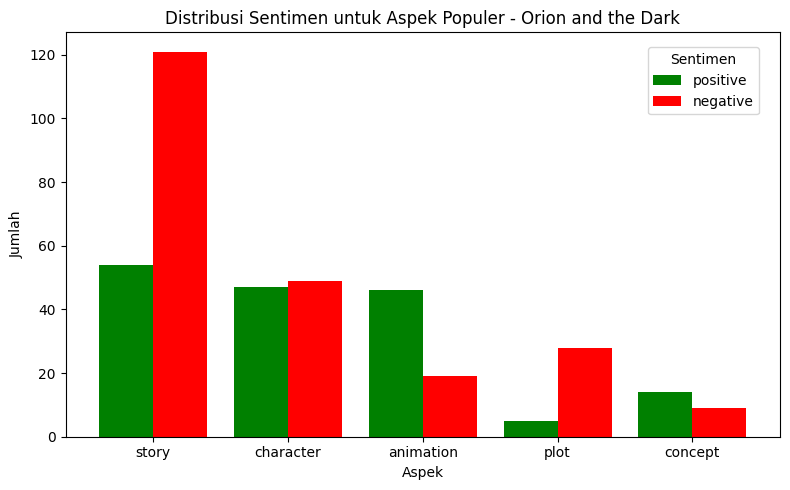

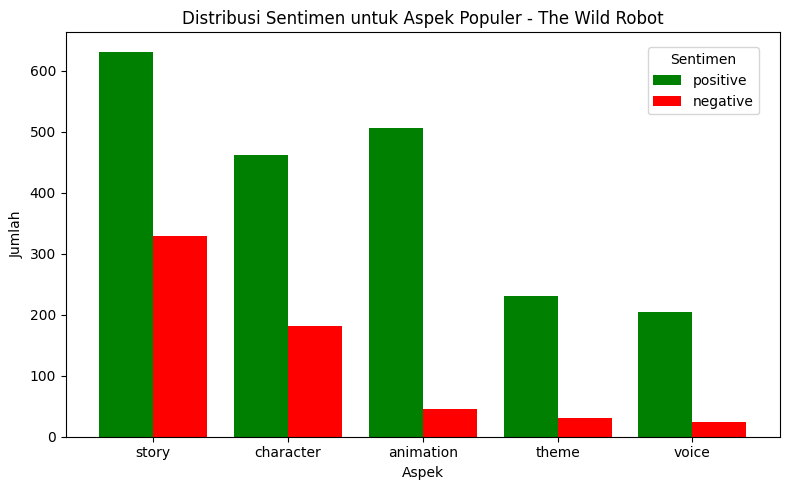

In [14]:
import matplotlib.pyplot as plt

# Ambil daftar film unik
movies = pipeline_results["Movie_Name"].unique()

for movie in movies:
    # Filter data untuk film tertentu
    movie_df = pipeline_results[pipeline_results["Movie_Name"] == movie]

    # Ambil aspek populer (5 teratas per film)
    top_aspects_movie = (
        movie_df.groupby("aspect_lemma")
        .size()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

    # Filter hanya aspek populer
    popular_df = movie_df[movie_df["aspect_lemma"].isin(top_aspects_movie)]

    # Hitung distribusi sentimen untuk setiap aspek
    sentiment_dist = (
        popular_df.groupby(["aspect_lemma", "Predicted_Sentiment"])
        .size()
        .reset_index(name="count")
    )

    # Pivot untuk visualisasi grouped bar
    pivot_df = sentiment_dist.pivot(
        index="aspect_lemma",
        columns="Predicted_Sentiment",
        values="count"
    ).fillna(0)

    # Pastikan semua kolom ada
    for col in ["positive", "negative"]:
        if col not in pivot_df.columns:
            pivot_df[col] = 0
    pivot_df = pivot_df[["positive", "negative"]]

    # Urutkan berdasarkan jumlah total (positif+negatif)
    pivot_df = pivot_df.reindex(
        pivot_df.sum(axis=1).sort_values(ascending=False).index
    )

    # Plot
    pivot_df.plot(
        kind="bar",
        stacked=False,
        figsize=(8, 5),
        color=["green", "red"],
        width=0.8
    )

    plt.title(f"Distribusi Sentimen untuk Aspek Populer - {movie}")
    plt.xlabel("Aspek")
    plt.ylabel("Jumlah")
    plt.xticks(rotation=0)  # label horizontal
    plt.legend(title="Sentimen", loc="upper right", bbox_to_anchor=(0.98, 0.98))
    plt.tight_layout()
    plt.show()

In [ ]:
# import pandas as pd

# # --- Filter aspek tertentu dari pipeline_results ---
# pd.set_option('display.max_colwidth', None)

# # 1. Aspek: plot
# plot_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'plot']
# print("Contoh review dengan aspek 'plot':")
# print(plot_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# # 2. Aspek: villain
# villain_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'villain']
# print("\nContoh review dengan aspek 'villain':")
# print(villain_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# # 3. Aspek: animation
# animation_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'animation']
# if (animation_df['Predicted_Sentiment'] == 'positive').sum() > (animation_df['Predicted_Sentiment'] == 'negative').sum():
#     print("\nContoh review dengan aspek 'animation' (positif lebih dominan):")
#     print(animation_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# # 4. Aspek: character
# character_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'character']
# if (character_df['Predicted_Sentiment'] == 'positive').sum() > (character_df['Predicted_Sentiment'] == 'negative').sum():
#     print("\nContoh review dengan aspek 'character' (positif lebih dominan):")
#     print(character_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# # 5. Aspek: story
# story_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'story']
# if (story_df['Predicted_Sentiment'] == 'positive').sum() > (story_df['Predicted_Sentiment'] == 'negative').sum():
#     print("\nContoh review dengan aspek 'story' (positif lebih dominan):")
#     print(story_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

In [ ]:
# ### 🔹 2. Wordcloud Aspek Dominan

# from wordcloud import WordCloud

# wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(aspect_counts))

# plt.figure(figsize=(12, 6))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# # plt.title("WordCloud Aspek yang Paling Sering Muncul")
# plt.show()